In [22]:
import numpy as np
from besta import Reader
import pandas as pd
import matplotlib.pyplot as plt
from besta.postprocess import summarize_results
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

In [23]:
nspec_folder = 'nspec'
sheets_folder = 'sheets'
plots_folder = 'plots'
example_nspec = 48

# Timescales / Postprocessing

In [24]:
# Load via the results file BESTA wrote
reader = Reader.from_results_file(f"./output/{nspec_folder}/{example_nspec}/fit_all.txt")
reader.load_results()
table = reader.results_table
display(table[-10:])


summary = summarize_results(
    table,
    parameter_keys=[
        "stars.sfh--t_at_frac_0.9000",
        "stars.sfh--t_at_frac_0.9900",
        "extra--stellar_mass"],
    percentiles=[0.16, 0.5, 0.84]
)

stars.sfh--alpha_powerlaw,stars.sfh--ism_metallicity_today,stars.sfh--t_at_frac_0.1000,stars.sfh--t_at_frac_0.3000,stars.sfh--t_at_frac_0.5000,stars.sfh--t_at_frac_0.7000,stars.sfh--t_at_frac_0.9000,stars.sfh--t_at_frac_0.9900,kinematics--los_vel,kinematics--los_sigma,dust.extinction--a_v,parameters--alpha_powerlaw,parameters--ism_metallicity_today,extra--stellar_mass,prior,post
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.11485483888009232,0.03530356129309034,0.6670216924258304,0.717727141988677,2.2523269506115304,2.3151852129120325,4.87922611884924,10.672849763126036,58.91788566276949,151.89334248519773,0.6884123521652115,0.322679683995745,0.07451317367207753,10.41771518142513,-24.576228827279277,-22.418907097011363
0.0948167274783491,0.0776265326914857,0.11019626854391484,1.6495888704816852,4.74437767191086,6.820853332792435,10.386505522363517,12.5480866921482,73.19431014410631,122.7229474327626,1.1120048296005642,2.575546899125424,0.07994731579833003,10.223285260368028,-24.576228827279277,-22.569167109599924
0.20571970684613944,0.02459783732437988,0.08110132478490362,2.697696202035456,3.2628414246825503,5.44741788262705,10.322776599569353,11.769013438010468,6.148965431477078,284.87431084926703,1.4534821634357544,1.1532944927779007,0.07904725289650072,10.44136404338523,-24.576228827279277,-22.29961762379591
0.5661190766173059,0.06477881075667791,0.38254889782944507,0.85627689102582,2.375259715039297,2.8618861771235244,3.411561999451104,11.796733868173336,3.258210310124781,244.2351399267695,1.412069376436965,1.8313156115057325,0.07797690648712877,10.585371630217047,-24.576228827279277,-22.286645565148483
0.4319090854247234,0.05924327953050307,0.5793543112081326,0.643650158356315,6.33497170179851,9.163014033525535,11.735209775515392,12.351679788240942,68.04105397655849,156.08033868982062,0.6594558391739143,1.416855500963704,0.07955932019824621,10.026172222748405,-24.576228827279277,-22.91113822598223
0.3540347110255711,0.03125870468893662,3.836379605990491,5.0161551682715135,6.153984245144764,7.2463178212828945,8.11807759566003,8.898356277308244,-39.644108891746775,260.7580918991419,0.9936138745020237,1.527958472082967,0.07955819692678394,10.353555579309441,-24.576228827279277,-22.342657665628142
0.2684559300951056,0.014425449109053561,0.459328604784479,6.266907842813914,7.38803827822856,8.705674383068322,9.07194720239459,9.49415424391935,24.916137348680046,313.0901027520571,1.2450608583448926,1.5158049465105385,0.07561946754436775,10.290301197364661,-24.576228827279277,-22.332995129914337
0.262502501158009,0.04652049513354548,3.477296742423656,3.554137935326039,3.953928427691152,4.304555070989838,6.091046898118919,9.088798100731616,96.4019459060105,69.28324377566756,1.2318992014281582,0.3343082590290014,0.07568094135628425,10.53724564508019,-24.576228827279277,-22.413087534122468
0.31229747546675896,0.024502120574657577,0.45717144432649315,1.3380501796096005,2.8536811441518752,3.4079096973840195,4.247745493801833,9.861971200417004,-54.32602789228886,342.88125239022145,0.7089255974307977,0.6903861579424819,0.07782864251733988,10.379561747189493,-24.576228827279277,-22.401124110240318


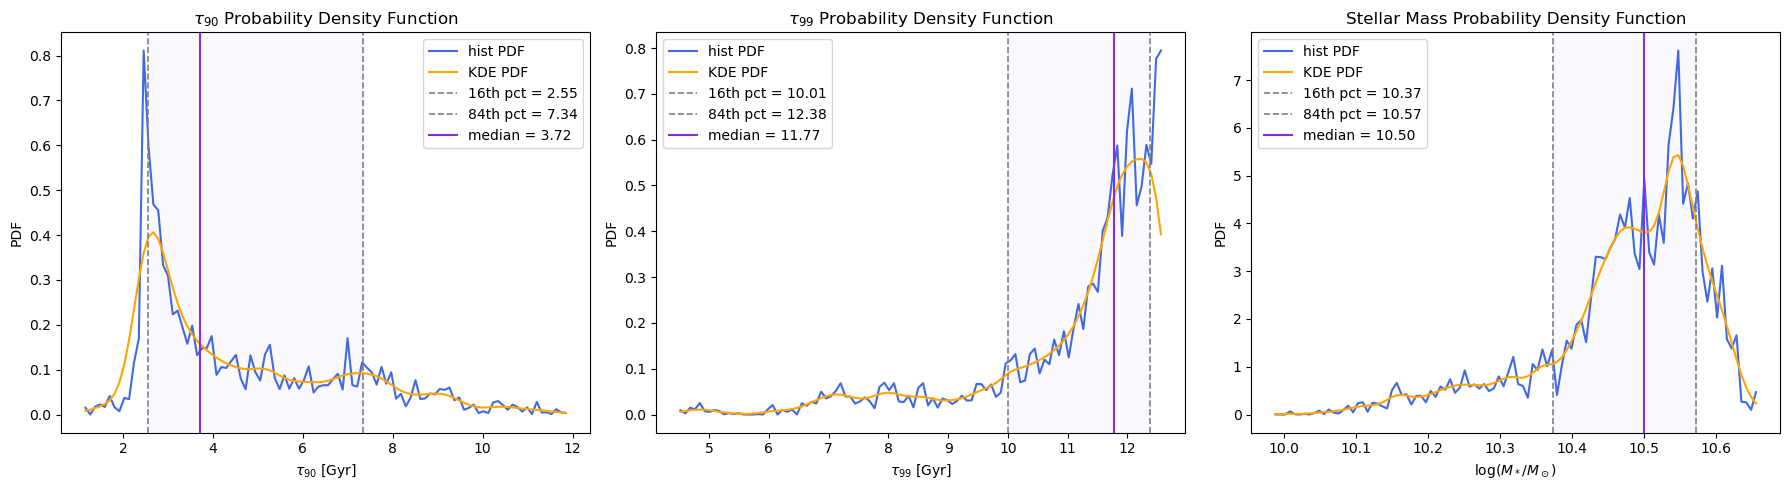

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

panels = [
    ("t_at_frac_0.9000",    r'$\tau_{90}$ [Gyr]',    r'$\tau_{90}$ Probability Density Function'),
    ("t_at_frac_0.9900",    r'$\tau_{99}$ [Gyr]',    r'$\tau_{99}$ Probability Density Function'),
    ("stellar_mass",        r'$\log(M_*/M_\odot)$', 'Stellar Mass Probability Density Function'),
]

for i, (ax, (key, xlabel, title)) in enumerate(zip(axes, panels)):
    grid     = summary.pdf_1d[key]["grid"]
    hist_pdf = summary.pdf_1d[key]["hist_pdf"]
    kde_pdf  = summary.pdf_1d[key]["kde_pdf"]

    p16, p50, p84 = summary.percentiles_values[i]

    ax.plot(grid, hist_pdf, color='royalblue', label='hist PDF')
    ax.plot(grid, kde_pdf,  color='orange',    label='KDE PDF')

    # shaded 16th-84th percentile region
    ax.axvspan(p16, p84, color='lavender', alpha=0.2)

    # vertical lines, with values baked into the labels
    ax.axvline(p16, color='gray', linestyle='--', linewidth=1.2,
               label=f'16th pct = {p16:.2f}')
    ax.axvline(p84, color='gray', linestyle='--', linewidth=1.2,
               label=f'84th pct = {p84:.2f}')
    ax.axvline(p50, color='blueviolet', linestyle='-', linewidth=1.5,
               label=f'median = {p50:.2f}')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel('PDF')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('plots/example_pdfs.pdf')
plt.show()

In [26]:
summary.corner_plot(f"{plots_folder}/corner.png")

'plots/corner.png'

In [27]:
A2142_einasto = pd.read_csv('sheets/A2142_einasto.csv')
A2142_gauss = pd.read_csv('sheets/A2142_gaussian.csv')
extras = [449, 902] # extras from the gaussian redshift
nspecs_A2142 = A2142_gauss['NSPEC'].tolist() + extras

In [28]:
def weighted_percentile(data, weights):
    data = np.array(data)
    weights = np.array(weights)
    
    sorter = np.argsort(data)
    data = data[sorter]
    weights = weights[sorter]

    total = np.sum(weights)

    if total == 0:
        return np.nan, np.nan, np.nan
    
    cdf = np.cumsum(weights) / total
    p16 = np.interp(0.16, cdf, data)
    p50 = np.interp(0.50, cdf, data)
    p84 = np.interp(0.84, cdf, data)
    return p16, p50, p84

def extract_post(nspec):
        
    reader = Reader.from_results_file(f"./output/{nspec_folder}/{nspec}/fit_all.txt")
    reader.load_results()
    table = reader.results_table
    
    t90s = table['stars.sfh--t_at_frac_0.9000'].data
    t99s = table['stars.sfh--t_at_frac_0.9900'].data
    m_star = table['extra--stellar_mass'].data
    post = table['post'].data
    
    log_w = post - post.max()
    w = np.exp(log_w)
    w = w / w.sum()

    return t99s, t90s, m_star, log_w, w

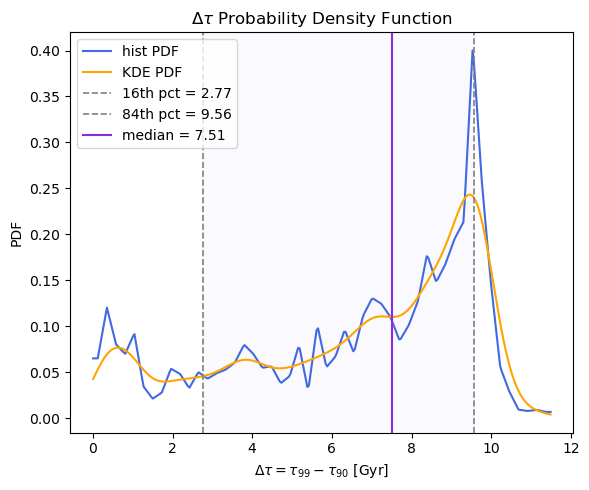

In [31]:
from scipy.stats import gaussian_kde

# ── Same pipeline as the batch loop, for the example galaxy ──────────────
t99s, t90s, m_star, log_w, w = extract_post(example_nspec)

delta_t = t99s - t90s
p16, p50, p84 = weighted_percentile(delta_t, w)

# ── Build PDF on a grid from the weighted samples ─────────────────────────
grid = np.linspace(delta_t.min(), delta_t.max(), 300)

kde      = gaussian_kde(delta_t, weights=w)
kde_pdf  = kde(grid)

counts, edges = np.histogram(delta_t, bins=50, weights=w, density=True)
hist_pdf = np.interp(grid, 0.5 * (edges[:-1] + edges[1:]), counts)

# ── Plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(grid, hist_pdf, color='royalblue', label='hist PDF')
ax.plot(grid, kde_pdf,  color='orange',    label='KDE PDF')

ax.axvspan(p16, p84, color='lavender', alpha=0.2)
ax.axvline(p16, color='gray',       linestyle='--', linewidth=1.2, label=f'16th pct = {p16:.2f}')
ax.axvline(p84, color='gray',       linestyle='--', linewidth=1.2, label=f'84th pct = {p84:.2f}')
ax.axvline(p50, color='blueviolet', linestyle='-',  linewidth=1.5, label=f'median = {p50:.2f}')

ax.set_xlabel(r'$\Delta\tau = \tau_{99} - \tau_{90}$ [Gyr]')
ax.set_ylabel('PDF')
ax.set_title(r'$\Delta\tau$ Probability Density Function')
ax.legend()

plt.tight_layout()
plt.savefig('plots/delta_t_pdf.pdf')
plt.show()

In [18]:
results = []

for i, nspec in enumerate(nspecs_A2142):
    try:
        t99s, t90s, m_star, log_w, w = extract_post(nspec)
        p16, p50, p84 = weighted_percentile(t99s-t90s, w)
        err_hi = p84-p50
        err_lo = p50-p16

        p16_t99, p50_t99, p84_t99 = weighted_percentile(t99s, w)
        err_hi_t99 = p84_t99-p50_t99 
        err_lo_t99 = p50_t99-p16_t99

        p16_m, p50_m, p84_m = weighted_percentile(t99s, w)
        err_hi_m = p84_m-p50_m 
        err_lo_m = p50_m-p16_m

        print(f"nspec: {nspec} : timescale = {p50:.3f} +{err_hi:.3f}/-{err_lo:.3f} Gyr")

        results.append({
            'nspec':      nspec,
            'timesc':     p50,
            'err_lo':     err_lo,
            'err_hi':     err_hi,
            't99':        p50_t99,
            'err_lo_t99': err_lo_t99,
            'err_hi_t99': err_hi_t99,
            'm_star':     p50_m,
            'err_lo_m':   err_lo_m,
            'err_hi_m':   err_hi_m,
        })

    except FileNotFoundError:
        print(f"nspec {nspec}: no results file found, skipping")
        continue
    
timesc_df = pd.DataFrame(results)
timesc_df.to_csv(f'{sheets_folder}/timesc.csv', index=False)

nspec: 5 : timescale = 2.344 +3.076/-1.580 Gyr
nspec: 6 : timescale = 0.273 +0.759/-0.247 Gyr
nspec: 8 : timescale = 2.182 +2.257/-1.856 Gyr
nspec: 11 : timescale = 5.821 +1.533/-4.673 Gyr
nspec: 16 : timescale = 1.158 +0.649/-0.876 Gyr
nspec: 17 : timescale = 1.320 +1.657/-0.704 Gyr
nspec: 24 : timescale = 2.257 +1.853/-1.648 Gyr
nspec: 26 : timescale = 6.651 +1.262/-4.651 Gyr
nspec: 27 : timescale = 0.807 +1.351/-0.639 Gyr
nspec: 28 : timescale = 0.998 +1.873/-0.868 Gyr
nspec: 29 : timescale = 0.377 +0.997/-0.324 Gyr
nspec: 30 : timescale = 2.085 +1.752/-1.238 Gyr
nspec: 35 : timescale = 4.465 +1.190/-3.485 Gyr
nspec: 37 : timescale = 4.299 +0.624/-1.658 Gyr
nspec: 41 : timescale = 3.980 +0.885/-2.127 Gyr
nspec: 47 : timescale = 7.348 +0.720/-2.318 Gyr
nspec: 48 : timescale = 7.515 +2.050/-4.746 Gyr
nspec: 49 : timescale = 1.691 +1.206/-1.338 Gyr
nspec: 51 : timescale = 3.145 +1.385/-2.614 Gyr
nspec: 55 : timescale = 0.931 +1.571/-0.700 Gyr
nspec: 58 : timescale = 2.580 +1.683/-1.883

# 3D Distances

In [22]:
# ── VARIABLES ────────────────────────────────────────────────
timesc_df = pd.read_csv(f'{sheets_folder}/timesc.csv')
timesc_df["nspec"] = timesc_df["nspec"].astype("Int64")
df = A2142_gauss.merge(timesc_df, left_on='NSPEC', right_on='nspec', how='left').drop(columns=['NSPEC'])

ra  = df["WEAVE_RA"].values
dec = df["WEAVE_DEC"].values
z   = df["Z_FINAL"].values

# Cosmological parameters (Einasto et al. 2015)
H0  = 100.0
h   = H0 / 100   # = 1.0
Om0 = 0.27
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)

# Cluster centre: Abell 2142 (Gr3070, Tempel et al. 2014b)
RA_CENTRE       = 239.52
DEC_CENTRE      = 27.32
Z_CENTRE        = 0.0888
FILAMENT_PA_DEG = 63.0    # PA = 63° CCW from west, where west = left = +RA direction
# CCW from left goes downward toward south

# ── COMOVING DISTANCE ─────────────────────────────────────────────────────

def comoving_distance(z):
    d_Mpc = cosmo.comoving_distance(z).to(u.Mpc).value
    return d_Mpc * h   # h = 1.0, so d [h^-1 Mpc] = d [Mpc]

# ── CARTESIAN PROJECTION ──────────────────────────────────────────────────

def to_cartesian(ra_deg, dec_deg, d_comov):
    ra  = np.radians(ra_deg)
    dec = np.radians(dec_deg)
    x =  d_comov * np.cos(dec) * np.cos(ra)
    y =  d_comov * np.cos(dec) * np.sin(ra)
    z =  d_comov * np.sin(dec)
    return x, y, z
    
# ── FILAMENT AXIS ─────────────────────────────────────────────────────────

def build_filament_axis(ra_c, dec_c, z_c, pa_deg):
    d_c = comoving_distance(z_c)                          # get comoving distance to the cluster centre    
    xc, yc, zc = to_cartesian(ra_c, dec_c, d_c)           # convert the cluster centre (RA, Dec, d_c) into 3D Cartesian coordinates
    centre = np.array([xc, yc, zc])                       # store the cluster centre as a 3D position vector in h^-1 Mpc
    ra_r, dec_r = np.radians(ra_c), np.radians(dec_c)     # convert ra and dec of the galaxies into radians
    
    # west points left from the cluster center
    west_hat  = np.array([-np.cos(dec_r) * np.sin(ra_r),  # the unit vector that points east (+RA direction) at the cluster centre
                           np.cos(dec_r) * np.cos(ra_r),  # This is the partial derivative of the Cartesian position vector with respect to RA
                           0.0])                                                                   
    west_hat /= np.linalg.norm(west_hat)                  # normalize to unit length
    
    # north points up from the cluster center
    north_hat = np.array([-np.sin(dec_r) * np.cos(ra_r),  # the unit vector pointing north (+Dec direction) at the cluster centre
                          -np.sin(dec_r) * np.sin(ra_r),  
                           np.cos(dec_r)])
    north_hat /= np.linalg.norm(north_hat)                # normalize to unit length
    pa_rad = np.radians(pa_deg)                           # convery position angle degrees -> radians
    # construct filament direction vector
    filament_hat = np.cos(pa_rad) * west_hat - np.sin(pa_rad) * north_hat  # cos(63) * west - sin(63) * north
    filament_hat /= np.linalg.norm(filament_hat)
    return centre, filament_hat

# ── DISTANCE CALCULATIONS ─────────────────────────────────────────────────

def filament_distances(pos, centre, filament_hat):
    delta   = pos - centre
    D_along = delta @ filament_hat
    perp    = delta - np.outer(D_along, filament_hat)
    D_fil   = np.linalg.norm(perp, axis=1)
    return D_along, D_fil

# ── RUN ───────────────────────────────────────────────────────────────────

print(f"Comoving Distance at Cluster Centre: {comoving_distance(Z_CENTRE)} [h^-1 Mpc]")
d_comov = comoving_distance(z)
x, y, z_cart = to_cartesian(ra, dec, d_comov)

centre, filament_hat = build_filament_axis(RA_CENTRE, DEC_CENTRE, Z_CENTRE, FILAMENT_PA_DEG)

pos = np.column_stack([x, y, z_cart])
D_along, D_fil = filament_distances(pos, centre, filament_hat)
is_mem = D_fil <= 7

# Attach results back to dataframe (all in units h^-1 Mpc)
df["D_along"] = D_along
df["D_fil"]   = D_fil
df["is_member"] = is_mem

# ── Summary ───────────────────────────────────────────────────────────────────
display(df[['nspec','WEAVE_RA', 'WEAVE_DEC', 'Z_FINAL', "D_fil", "D_along"]].head(10).round(4))

Comoving Distance at Cluster Centre: 261.3263503725312 [h^-1 Mpc]


,nspec,WEAVE_RA,WEAVE_DEC,Z_FINAL,D_fil,D_along
0,5,239.4519,26.5165,0.0902,4.5157,3.1884
1,6,239.5913,26.4330,0.0855,9.7595,3.5992
2,8,239.9890,26.1963,0.0862,7.6982,5.2760
3,11,239.4771,26.5575,0.0876,3.8984,2.9789
4,16,239.6885,26.5764,0.0873,4.5814,3.2764
5,17,239.7066,26.3754,0.0866,6.6170,4.0809
6,24,240.0017,26.0657,0.0906,5.1708,6.1079
7,26,239.4487,26.6331,0.0864,7.1935,2.5883
8,27,239.5449,26.7026,0.0923,10.0814,2.6529
9,28,239.5837,26.5278,0.0883,2.0527,3.3183


# 2D Distances

In [23]:
z = np.full(len(ra), Z_CENTRE)

# ── RUN ───────────────────────────────────────────────────────────────────
d_comov = comoving_distance(z)
x, y, z_cart = to_cartesian(ra, dec, d_comov)

centre, filament_hat = build_filament_axis(RA_CENTRE, DEC_CENTRE, Z_CENTRE, FILAMENT_PA_DEG)

pos = np.column_stack([x, y, z_cart])
D_along_2D, D_fil_2D = filament_distances(pos, centre, filament_hat)
is_mem_2D = D_fil_2D <= 0.5

df["D_along_2D"] = D_along_2D
df["D_fil_2D"]   = D_fil_2D
df["is_member_2D"] = is_mem_2D

# ── Summary ───────────────────────────────────────────────────────────────────
display(df[['nspec','WEAVE_RA', 'WEAVE_DEC', 'Z_FINAL', "D_fil_2D", "D_along_2D", "is_member_2D"]].head(10).round(4))

,nspec,WEAVE_RA,WEAVE_DEC,Z_FINAL,D_fil_2D,D_along_2D,is_member_2D
0,5,239.4519,26.5165,0.0902,1.9116,3.1392,False
1,6,239.5913,26.4330,0.0855,1.5775,3.7366,False
2,8,239.9890,26.1963,0.0862,0.6173,5.4344,False
3,11,239.4771,26.5575,0.0876,1.7347,3.0191,False
4,16,239.6885,26.5764,0.0873,0.9271,3.3334,False
5,17,239.7066,26.3754,0.0866,1.2766,4.1844,False
6,24,240.0017,26.0657,0.0906,0.8396,5.9894,False
7,26,239.4487,26.6331,0.0864,1.6812,2.6594,False
8,27,239.5449,26.7026,0.0923,1.1880,2.5549,False
9,28,239.5837,26.5278,0.0883,1.4089,3.3371,False


In [24]:
df.to_csv(f'{sheets_folder}/2D_Gauss_dist_timesc.csv', index=False)